# Reinforcement Learning : rapport de projet

Implémentation et comparaison des algorithmes classiques de Reinforcement
Learning, Dynamic Programming, Monte Carlo, Temporal Difference et
Planning, sur 8 environnements, du plus simple, résultat optimal
calculable à la main, à des environnements boîte noire sans documentation.

La plupart des cellules se contentent de recharger des modèles déjà
entraînés, aucun réentraînement n'est nécessaire pour lire ce rapport.
Quelques cellules réentraînent en direct, rapidement, pour montrer que
l'apprentissage fonctionne aussi en temps réel.

In [1]:
# Se placer à la racine du projet pour que les imports et les chemins
# vers saved_models/ fonctionnent.
import os
import sys

RACINE = os.path.abspath("..")
os.chdir(RACINE)
sys.path.insert(0, RACINE)

import random
import matplotlib.pyplot as plt

from utils.io import charger_politique, charger_Q, charger_V

print("Répertoire de travail :", os.getcwd())

Répertoire de travail : /home/nicolas/Documents/ESGI/2025-2026/deeplearning/reinforcement/projet


## 1. Introduction

Ce rapport présente l'implémentation et la comparaison des familles
classiques d'algorithmes de Reinforcement Learning :

- Dynamic Programming, Policy Iteration et Value Iteration, qui nécessite
  un modèle complet de l'environnement, avec les probabilités de
  transition et les récompenses connues à l'avance.
- Monte Carlo, exploring starts, on-policy first-visit et off-policy par
  importance sampling, qui apprend uniquement à partir d'épisodes complets
  joués dans l'environnement.
- Temporal Difference, Sarsa et Q-Learning, qui apprend à chaque pas, sans
  attendre la fin de l'épisode.
- Planning, Dyna-Q, qui combine apprentissage direct et un modèle appris,
  rejoué en simulation pour accélérer l'apprentissage.

Ces algorithmes sont testés sur 8 environnements, du plus simple, Line
World, dont le résultat optimal est calculable à la main, à des
environnements boîte noire fournis sans aucune documentation, les secret
envs 0 à 3.

Principe d'architecture : un algorithme ne dépend jamais d'un
environnement concret, seulement d'un contrat abstrait, décrit en section
2. Cela permet de tester n'importe quel algorithme sur n'importe quel
environnement sans adapter son code, et de vérifier chaque implémentation
contre un résultat exact connu à l'avance avant de l'étendre à des cas
plus complexes où ce résultat n'existe pas.

## 2. Les deux contrats d'environnement

Le premier contrat correspond à un modèle complet connu : les
probabilités de transition et les récompenses associées sont connues à
l'avance. Il est requis pour Policy Iteration et Value Iteration, et
implémenté par Line World, Monty Hall 1 et 2, Grid World, Rock Paper
Scissors, mais pas par les secret envs, qui sont des boîtes noires
(section 7).

Le second contrat ne donne accès qu'à une remise à zéro, un pas et un
score cumulé, sans méthode de récompense séparée. La récompense d'un pas
se reconstitue par différence de score, le score avant l'action est
soustrait au score après l'action. Ce contrat est requis pour Monte
Carlo, Temporal Difference et Planning. Tous les environnements
l'implémentent, y compris les secret envs.

Avoir les deux contrats sur le même environnement, Line World, Monty Hall
1 et 2, Grid World, Rock Paper Scissors, permet de vérifier les
algorithmes model-free contre un optimum exact calculé par Policy ou
Value Iteration. C'est la méthode utilisée dans tout ce rapport, sauf
pour les secret envs où c'est impossible (section 7).

## 3. Algorithmes, validation par famille

Chaque famille est d'abord validée sur Line World et Monty Hall niveau 1,
les deux environnements les plus simples, où le résultat optimal est
connu à l'avance, calculable à la main ou résultat théorique classique.
C'est la méthode systématiquement utilisée avant d'étendre à des
environnements plus complexes.

### 3.1 Dynamic Programming

Les équations d'optimalité de Bellman définissent la valeur optimale d'un
état comme le maximum, sur les actions possibles, de l'espérance de la
récompense immédiate plus la valeur actualisée de l'état suivant. La
valeur optimale d'une action se définit de façon similaire, en prenant
ensuite le maximum sur les actions futures.

Policy Iteration alterne évaluation complète de la politique courante,
jusqu'à convergence, et amélioration gloutonne.

Value Iteration fusionne les deux en un seul balayage par itération, ce
qui le rend plus rapide (section 5.1).

Les modèles déjà sauvegardés contiennent le résultat de Policy Iteration
pour Line World et Monty Hall 1, rechargé ci-dessous. Value Iteration
n'y est pas sauvegardé, il est quasi instantané à recalculer : on le
relance en direct pour vérifier qu'il retrouve exactement le même
résultat.

In [2]:
from algorithms.dynamic_programming import value_iteration
from environments.line_world import LineWorld
from environments.monty_hall_1 import MontyHall1

# --- Line World : rechargé ---
V_pi = charger_V("saved_models/line_world/V_policy_iteration.json")
politique_pi = charger_politique("saved_models/line_world/politique_policy_iteration.json")
print("Line World — Policy Iteration (rechargé)")
print("  V* =", V_pi)
print("  politique (0=gauche, 1=droite) =", [politique_pi.meilleure_action(s) for s in range(5)])

# --- Value Iteration : recalculé (instantané), pour vérifier l'accord ---
_, V_vi = value_iteration(LineWorld(), gamma=0.999999)
print("  V* (Value Iteration, recalculé) =", [round(v, 6) for v in V_vi])
print()

# --- Monty Hall 1 : rechargé ---
V_pi_mh1 = charger_V("saved_models/monty_hall_1/V_policy_iteration.json")
politique_pi_mh1 = charger_politique("saved_models/monty_hall_1/politique_policy_iteration.json")
print("Monty Hall 1 — Policy Iteration (rechargé)")
print("  V* =", V_pi_mh1)
print("  politique aux 3 états post-choix (0=garder, 1=changer) =",
      [politique_pi_mh1.meilleure_action(s) for s in (1, 2, 3)])

_, V_vi_mh1 = value_iteration(MontyHall1(), gamma=1.0)
print("  V* (Value Iteration, recalculé) =", [round(v, 6) for v in V_vi_mh1])

Line World — Policy Iteration (rechargé)
  V* = [0.0, 0.9999980000009999, 0.999999, 1.0, 0.0]
  politique (0=gauche, 1=droite) = [0, 1, 1, 1, 0]
  V* (Value Iteration, recalculé) = [0.0, 0.999998, 0.999999, 1.0, 0.0]

Monty Hall 1 — Policy Iteration (rechargé)
  V* = [0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.0]
  politique aux 3 états post-choix (0=garder, 1=changer) = [1, 1, 1]
  V* (Value Iteration, recalculé) = [0.666667, 0.666667, 0.666667, 0.666667, 0.0]


### 3.2 Monte Carlo

Le retour d'un épisode se calcule en remontant les pas un par un, en
cumulant la récompense actualisée à chaque étape, avec une mise à jour à
la première visite de chaque couple état-action.

Monte Carlo ES, exploring starts, fait démarrer chaque épisode sur un
couple état-action tiré au hasard, ce qui garantit l'exploration sans
politique epsilon-soft.

On-policy first-visit dérive une politique epsilon-greedy de la table de
valeurs Q, sans besoin de démarrage forcé.

Off-policy, par importance sampling, utilise une politique de
comportement epsilon-greedy pour générer les épisodes, et apprend une
politique cible gloutonne, en pondérant chaque mise à jour par l'inverse
de la probabilité sous la politique de comportement, tant que celle-ci
suit la politique cible.

Le modèle de Monte Carlo ES est rechargé ci-dessous. L'algorithme
off-policy n'a pas de modèle sauvegardé pour ces deux environnements : il
est réentraîné en direct ci-dessous.

In [3]:
from algorithms.monte_carlo import off_policy_mc_control
from environments.line_world import LineWorldEnv
from environments.monty_hall_1 import MontyHall1Env

Q_mc_es = charger_Q("saved_models/line_world/Q_mc_es.json")
print("Line World — MC ES (rechargé), Q par état non terminal :")
for s in (1, 2, 3):
    print(f"  état {s} : {Q_mc_es[s]}")
print()

# --- Démonstration d'entraînement en direct : off-policy MC control ---
print("Entraînement en direct (off-policy MC, importance sampling)...")

politique, Q_off = off_policy_mc_control(
    LineWorldEnv(), n_episodes=5000, gamma=0.999999, epsilon=0.2, rng=random.Random(0)
)
print("Line World — off-policy MC (entraîné à l'instant) :")
for s in (1, 2, 3):
    print(f"  état {s} : action {politique.meilleure_action(s)} (1=droite attendu)  Q={Q_off[s]}")

politique_mh1, Q_off_mh1 = off_policy_mc_control(
    MontyHall1Env(), n_episodes=20000, gamma=1.0, epsilon=0.2, rng=random.Random(0)
)
print("\nMonty Hall 1 — off-policy MC (entraîné à l'instant) :")
for s in (1, 2, 3):
    print(f"  état {s} : action {politique_mh1.meilleure_action(s)} (1=changer attendu)  Q={Q_off_mh1[s]}")

Line World — MC ES (rechargé), Q par état non terminal :
  état 1 : [-1.0, 0.9989448183264246]
  état 2 : [0.9984955030059993, 0.99948153712807]
  état 3 : [0.9965318058935353, 1.0]

Entraînement en direct (off-policy MC, importance sampling)...
Line World — off-policy MC (entraîné à l'instant) :
  état 1 : action 1 (1=droite attendu)  Q=[-1.0, 0.9999980000009999]
  état 2 : action 1 (1=droite attendu)  Q=[0.9999970000029998, 0.999999]
  état 3 : action 1 (1=droite attendu)  Q=[0.9999980000009999, 1.0]

Monty Hall 1 — off-policy MC (entraîné à l'instant) :
  état 1 : action 1 (1=changer attendu)  Q=[0.32830820770519253, 0.667332268370608, 0.0]
  état 2 : action 1 (1=changer attendu)  Q=[0.3028571428571428, 0.6616094986807386, 0.0]
  état 3 : action 1 (1=changer attendu)  Q=[0.3221957040572793, 0.6678605748230976, 0.0]


### 3.3 Temporal Difference

Apprentissage à chaque pas, par bootstrap sur l'estimation courante, sans
attendre la fin de l'épisode comme Monte Carlo.

Sarsa, on-policy, met à jour la table de valeurs en utilisant l'action
réellement choisie ensuite, tirée selon une politique epsilon-greedy.

Q-Learning, off-policy, met à jour la table de valeurs en utilisant la
meilleure action possible dans l'état suivant, indépendamment de l'action
réellement choisie ensuite.

Le modèle de Q-Learning est rechargé ci-dessous. Sarsa n'a pas de modèle
sauvegardé pour ces deux environnements : réentraîné en direct, rapide
sur ces tailles d'état.

In [4]:
from algorithms.temporal_difference import sarsa

Q_ql = charger_Q("saved_models/line_world/Q_q_learning.json")
print("Line World — Q-Learning (rechargé), Q par état non terminal :")
for s in (1, 2, 3):
    print(f"  état {s} : {Q_ql[s]}")

Q_sarsa = sarsa(LineWorldEnv(), nb_episodes=5000)
print("\nLine World — Sarsa (entraîné à l'instant), Q par état non terminal :")
for s in (1, 2, 3):
    print(f"  état {s} : {Q_sarsa[s]}")

Q_sarsa_mh1 = sarsa(MontyHall1Env(), nb_episodes=20000, gamma=1.0)
print("\nMonty Hall 1 — Sarsa (entraîné à l'instant), Q aux 3 états post-choix :")
for s in (1, 2, 3):
    print(f"  état {s} : {Q_sarsa_mh1[s]}")

Line World — Q-Learning (rechargé), Q par état non terminal :
  état 1 : [-0.5217031000000001, 0.9999902898787689]
  état 2 : [0.9999113000457581, 0.999998999999999]
  état 3 : [0.99999785149239, 0.9999999999999996]



Line World — Sarsa (entraîné à l'instant), Q par état non terminal :
  état 1 : [-0.5695327900000001, 0.999839640352773]
  état 2 : [0.7565303556306731, 0.999998927245502]
  état 3 : [0.9996692352511437, 0.9999999999999996]



Monty Hall 1 — Sarsa (entraîné à l'instant), Q aux 3 états post-choix :
  état 1 : [0.1643696282868264, 0.5421761013402528, 0.0]
  état 2 : [0.20463197789870377, 0.4470079681055232, 0.0]
  état 3 : [0.3772480632083408, 0.631021743123795, 0.0]


### 3.4 Planning

Dyna-Q maintient, en plus de la table de valeurs, un modèle appris des
transitions réellement observées. Après chaque pas réel, plusieurs mises
à jour supplémentaires sont rejouées depuis ce modèle, en simulation, ce
qui accélère l'apprentissage sans interaction supplémentaire avec
l'environnement réel, à condition que le modèle soit fiable, voir le
piège trouvé sur Monty Hall 2 en section 5.4.

Dyna-Q n'a pas de modèle sauvegardé pour Line World et Monty Hall 1 :
réentraîné en direct, avec un budget d'épisodes volontairement réduit
pour montrer sa vitesse de convergence caractéristique.

In [5]:
from algorithms.planning import dyna_q

Q_dyna = dyna_q(LineWorldEnv(), nb_episodes=500, n_planification=10)
print("Line World — Dyna-Q (entraîné à l'instant, 500 épisodes seulement) :")
for s in (1, 2, 3):
    print(f"  état {s} : {Q_dyna[s]}")
print()
print("A comparer aux 5000 épisodes utilisés par Sarsa/Q-Learning ci-dessus pour un")
print("résultat de qualité comparable. Non testé sur Monty Hall 1 : sa récompense")
print("finale est déjà stochastique (comme la décision finale de Monty Hall 2), donc")
print("sujette à la même limite détaillée en section 5.4.")

Line World — Dyna-Q (entraîné à l'instant, 500 épisodes seulement) :
  état 1 : [-0.9999999999999996, 0.9999980000009985]
  état 2 : [0.9999970000029978, 0.999998999999999]
  état 3 : [0.9999980000009985, 0.9999999999999996]

A comparer aux 5000 épisodes utilisés par Sarsa/Q-Learning ci-dessus pour un
résultat de qualité comparable. Non testé sur Monty Hall 1 : sa récompense
finale est déjà stochastique (comme la décision finale de Monty Hall 2), donc
sujette à la même limite détaillée en section 5.4.


## 4. Les environnements

Pour chaque environnement : visualisation de l'état, rejeu pas à pas
d'une politique sauvegardée, et un mode où un humain peut jouer
manuellement. Ce mode manuel n'est pas exécutable dans un notebook non
interactif ; plusieurs environnements ont aussi leur propre mode manuel
enrichi, utilisable directement en ligne de commande.

In [6]:
from environments.line_world import LineWorldEnv

env = LineWorldEnv()
print("Line World — état initial :")
env.pretty_print()

Line World — état initial :
__X__


In [7]:
from environments.grid_world import GridWorld

env = GridWorld()
print("Grid World — état initial (A=agent, G=objectif, X=piège) :")
env.pretty_print()

Grid World — état initial (A=agent, G=objectif, X=piège) :
A . . X
. . . .
. . . .
. . . G
score = 0.0


In [8]:
from environments.monty_hall_1 import MontyHall1Env

env = MontyHall1Env()
env.reset()
print("Monty Hall niveau 1 — état initial :")
env.pretty_print()

Monty Hall niveau 1 — état initial :
[?] [?] [?]


In [9]:
from environments.monty_hall_2 import MontyHall2

env = MontyHall2(rng=random.Random(0))
print("Monty Hall niveau 2 — état initial :")
env.pretty_print()

Monty Hall niveau 2 — état initial :
Portes : A   B   C   D   E 
Décision 1/4
score = 0.0


In [10]:
from environments.rock_paper_scissors import TwoRoundRPS

env = TwoRoundRPS(rng=random.Random(0))
print("Two-Round Rock Paper Scissors — état initial :")
env.pretty_print()

Two-Round Rock Paper Scissors — état initial :
Round 1/2
  score = +0.0


In [11]:
from environments.secret_envs import secret_env_0

env = secret_env_0()
env.reset()
print("Secret Env 0 — état initial (display fourni par la lib du prof) :")
env.pretty_print()

Secret Env 0 — état initial (display fourni par la lib du prof) :
-------------------------
|   |
|   |
| E |
score: 0
-------------------------



### Rejeu pas à pas d'une politique sauvegardée, sans réentraîner

La fonction de rejeu attend normalement une touche entre chaque action
pour une démonstration en direct. Ci-dessous, ce mode pause est désactivé
pour dérouler la partie automatiquement dans le notebook.

In [12]:
from utils.interaction import rejouer_politique

Q_ql_line_world = charger_Q("saved_models/line_world/Q_q_learning.json")
score_final = rejouer_politique(LineWorldEnv(), Q_ql_line_world, pause=False)
print(f"\nScore final : {score_final:+.1f}")

__X__
action jouée : 1
___X_
score : 0.0
action jouée : 1
____X
score : 1.0

Score final : +1.0


## 5. Étude comparative

Les 4 familles d'algorithmes lancées sur Grid World, Monty Hall 2 et Rock
Paper Scissors, vérifiées contre l'optimum exact calculé par Policy ou
Value Iteration.

### 5.1 Dynamic Programming

Policy Iteration et Value Iteration convergent vers exactement la même
valeur optimale et la même politique sur les 3 environnements, bonne
confirmation croisée :

In [13]:
import time

from algorithms.dynamic_programming import policy_iteration, value_iteration
from environments.grid_world import GridWorld as GW
from environments.monty_hall_2 import MontyHall2 as MH2
from environments.rock_paper_scissors import TwoRoundRPS as RPS

for nom, fabrique, gamma in (("Grid World", GW, 0.999999), ("Monty Hall 2", MH2, 1.0), ("Rock Paper Scissors", RPS, 1.0)):
    t0 = time.perf_counter()
    pi_pol, V_pol = policy_iteration(fabrique(), gamma=gamma)
    t_pol = time.perf_counter() - t0

    t0 = time.perf_counter()
    pi_val, V_val = value_iteration(fabrique(), gamma=gamma)
    t_val = time.perf_counter() - t0

    identiques = all(abs(a - b) < 1e-6 for a, b in zip(V_pol, V_val))
    print(f"{nom:<22} Policy Iteration: {t_pol*1000:7.2f} ms   Value Iteration: {t_val*1000:6.2f} ms   V* identiques: {identiques}")

Grid World             Policy Iteration:  154.01 ms   Value Iteration:   9.70 ms   V* identiques: True
Monty Hall 2           Policy Iteration:    5.25 ms   Value Iteration:   3.91 ms   V* identiques: True


Rock Paper Scissors    Policy Iteration:    0.49 ms   Value Iteration:   0.24 ms   V* identiques: True


Sur Grid World, Policy Iteration est environ 16 fois plus lent que Value
Iteration, ce qui est cohérent avec la théorie : Policy Iteration refait
une évaluation complète à chaque étape d'amélioration, alors que Value
Iteration fusionne les deux en un seul balayage.

Rock Paper Scissors, malgré l'absence de politique optimale stationnaire
unique au round 1, les 3 actions y sont équivalentes par symétrie, se
résout très bien en Dynamic Programming.

### 5.2 Monte Carlo

Les 3 variantes, ES, on-policy et off-policy, retrouvent l'optimum exact
sur les 3 environnements. Ceci est vérifié en comparant la valeur de
l'action apprise à la valeur optimale de l'état, et non l'action choisie
par Policy Iteration, car plusieurs de ces environnements ont des actions
ex aequo : plusieurs chemins optimaux équivalents sur Grid World, et les
3 actions du round 1 de Rock Paper Scissors strictement équivalentes par
symétrie. Sur Monty Hall 2, on-policy et off-policy ont besoin d'un taux
d'exploration plus élevé, 0,2, et de plusieurs tentatives pour converger ;
Monte Carlo ES n'a pas ce problème grâce aux exploring starts (section
3.2).

Détail notable : sur Grid World, le taux d'épisodes abandonnés de Monte
Carlo ES, quand aucun état terminal n'est atteint en 10 000 pas, un
filet de sécurité de l'algorithme, varie énormément selon la graine
aléatoire utilisée, de 2% à 25% observés d'un essai à l'autre.

### 5.3 Temporal Difference

Sarsa et Q-Learning convergent tous les deux sur les 3 environnements.

Point théorique important : Sarsa est on-policy, comme vu en cours il
évalue la politique epsilon-greedy qu'il suit réellement dans sa mise à
jour, contrairement à Q-Learning, off-policy, qui évalue la politique
gloutonne indépendamment de l'action réellement choisie ensuite.
Sur Monty Hall 2, baisser le taux d'exploration pour se rapprocher en
théorie du comportement glouton pur a en fait aggravé la convergence, un
taux de réussite mesuré sur plusieurs graines de 5 sur 10 à un taux
d'exploration de 0,05, puis 4 sur 10 à 0,02, et seulement 1 sur 10 à
0,01. Sur cet arbre de décision profond, l'effet dominant est le déficit
d'exploration des branches rares, pas le biais lié au caractère
on-policy.

### 5.4 Planning

Sur Grid World et Rock Paper Scissors, des environnements déterministes,
Dyna-Q converge avec 3 fois moins d'épisodes réels que Q-Learning ou
Sarsa, 3000 contre 10 000 pour un résultat équivalent, ce qui est
l'intérêt attendu de la planification.

Sur Monty Hall 2, Dyna-Q échoue plus souvent, environ 30% de réussite,
contre environ 50% pour Sarsa et Q-Learning. La cause est différente du
problème ci-dessus : le modèle appris ne retient que la dernière
transition observée pour chaque couple état-action, pas une moyenne. À
la décision finale, la récompense est stochastique, gagné ou perdu, et
la planification rejoue ce seul échantillon plusieurs fois d'affilée, ce
qui biaise systématiquement la table de valeurs vers le bas, avec une
sous-estimation mesurée de 0,1 à 0,4 par rapport à la vraie valeur, au
lieu de moyenner comme le ferait un vrai pas de Q-Learning. C'est une
limite connue du Dyna-Q de base, décrite par Sutton et Barto : le modèle
y est supposé déterministe.

## 6. Étude d'hyperparamètres

Impact du taux d'exploration, du taux d'apprentissage, du facteur
d'actualisation et du nombre de mises à jour de planification pour
Dyna-Q sur la qualité de l'apprentissage, un hyperparamètre à la fois,
sur l'environnement où son effet est le plus lisible. La métrique
utilisée est l'erreur absolue moyenne entre la table de valeurs apprise
et la valeur exacte de chaque couple état-action, calculée à partir de
la valeur optimale donnée par Policy ou Value Iteration. Cette mesure
est plus fine que simplement vérifier si l'action gloutonne est
correcte, qui sature trop vite pour montrer une tendance. Chaque point
est une moyenne sur plusieurs graines aléatoires.

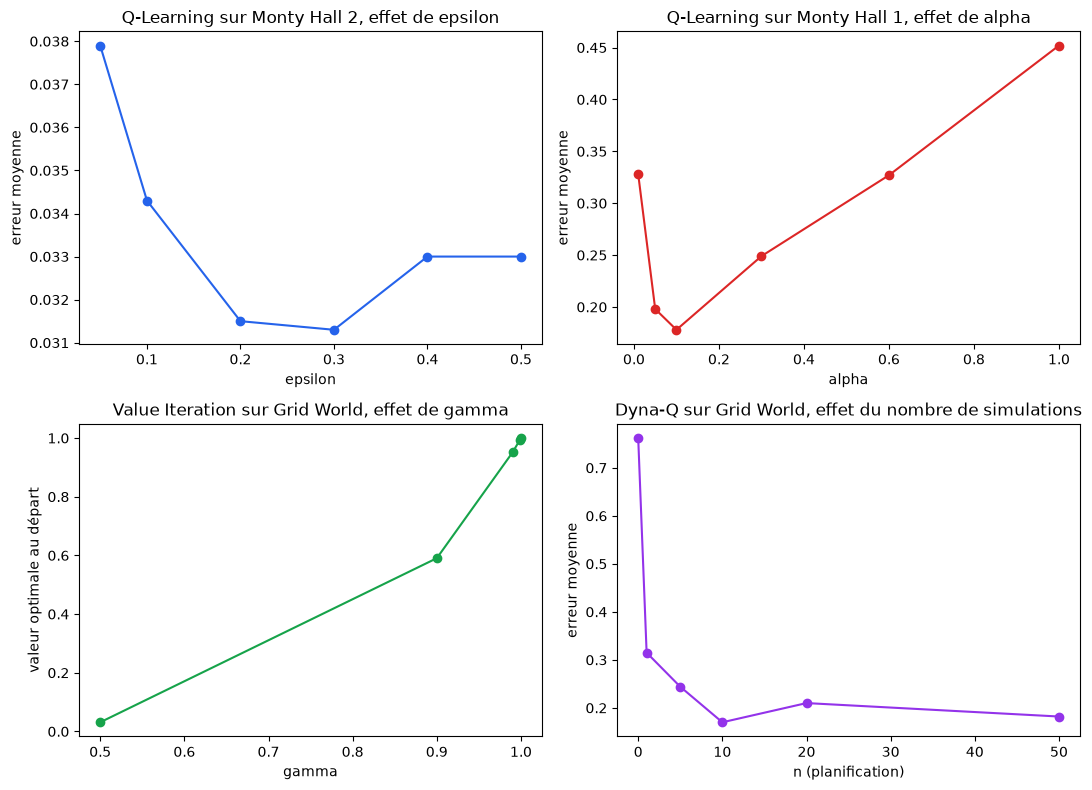

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# epsilon (Q-Learning, Monty Hall 2, 40000 episodes, 20 graines)
epsilons = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
erreurs_eps = [0.0379, 0.0343, 0.0315, 0.0313, 0.0330, 0.0330]
axes[0, 0].plot(epsilons, erreurs_eps, "o-", color="#2563eb")
axes[0, 0].set_title("Q-Learning sur Monty Hall 2, effet de epsilon")
axes[0, 0].set_xlabel("epsilon")
axes[0, 0].set_ylabel("erreur moyenne")

# alpha (Q-Learning, Monty Hall 1, 2000 episodes, 15 graines)
alphas = [0.01, 0.05, 0.1, 0.3, 0.6, 1.0]
erreurs_alpha = [0.328, 0.198, 0.178, 0.249, 0.327, 0.452]
axes[0, 1].plot(alphas, erreurs_alpha, "o-", color="#dc2626")
axes[0, 1].set_title("Q-Learning sur Monty Hall 1, effet de alpha")
axes[0, 1].set_xlabel("alpha")
axes[0, 1].set_ylabel("erreur moyenne")

# gamma (Value Iteration, Grid World, V*(depart))
gammas = [0.5, 0.9, 0.99, 0.999, 0.999999]
v_depart = [0.0312, 0.5905, 0.9510, 0.9950, 1.0000]
axes[1, 0].plot(gammas, v_depart, "o-", color="#16a34a")
axes[1, 0].set_title("Value Iteration sur Grid World, effet de gamma")
axes[1, 0].set_xlabel("gamma")
axes[1, 0].set_ylabel("valeur optimale au départ")

# n_planification (Dyna-Q, Grid World, 200 episodes reels, 15 graines)
ns = [0, 1, 5, 10, 20, 50]
erreurs_n = [0.762, 0.315, 0.244, 0.170, 0.210, 0.182]
axes[1, 1].plot(ns, erreurs_n, "o-", color="#9333ea")
axes[1, 1].set_title("Dyna-Q sur Grid World, effet du nombre de simulations")
axes[1, 1].set_xlabel("n (planification)")
axes[1, 1].set_ylabel("erreur moyenne")

plt.tight_layout()
plt.show()

Le taux d'exploration montre un décrochage net sous 0,1, les branches
rares de Monty Hall 2 sont sous-explorées, puis un plateau après environ
0,3.

Le taux d'apprentissage montre un creux net autour de 0,1, un compromis
classique entre biais et variance. Point notable : cet effet n'existe
que parce que Monty Hall 1 a une récompense stochastique. Le même test
sur Line World, déterministe, montre l'inverse : un taux d'apprentissage
de 1 y est optimal, l'erreur tombe à zéro dès 100 épisodes quel que soit
le taux testé, car sans bruit à moyenner, un taux élevé fait juste une
mise à jour exacte immédiate.

Le facteur d'actualisation dévalue une récompense lointaine, à 6 pas de
distance de l'objectif, sans changer la politique optimale ici, car le
chemin le plus court est unique. Il trancherait s'il existait plusieurs
chemins de longueurs différentes.

Le nombre de mises à jour de planification montre une chute nette de
l'erreur jusqu'à environ 10, puis des rendements décroissants. Ce même
mécanisme se retourne contre Dyna-Q sur récompense stochastique (section
5.4) : la planification aide quand le modèle est fiable, elle nuit quand
il ne l'est pas.

## 7. Secret Env 0 à 3

Ces environnements n'implémentent que le contrat model-free, pas le
contrat à modèle complet : pas de modèle, donc pas de Policy ou Value
Iteration possible, et pas d'optimum exact contre lequel vérifier. Les 6
algorithmes model-free ont donc été entraînés, 3000 épisodes chacun,
avec les mêmes hyperparamètres par défaut, et sont comparés ici par le
score moyen obtenu sur 200 parties rejouées avec la politique gloutonne
apprise, seule mesure de qualité disponible sans vérité terrain.

In [15]:
from environments.secret_envs import secret_env_0, secret_env_1, secret_env_2, secret_env_3

ALGOS = (
    ("MC ES", "Q_mc_es.json"),
    ("MC on-policy", "Q_mc_on_policy.json"),
    ("MC off-policy", "Q_off_policy_mc.json"),
    ("Sarsa", "Q_sarsa.json"),
    ("Q-Learning", "Q_q_learning.json"),
    ("Dyna-Q", "Q_dyna_q.json"),
)
NB_EPISODES_EVALUATION = 200


def _action_gloutonne(Q, s, actions_disponibles):
    meilleure = max(Q[s][a] for a in actions_disponibles)
    return next(a for a in actions_disponibles if Q[s][a] == meilleure)


def _score_moyen(fabrique, Q, nb_episodes):
    total = 0.0
    for _ in range(nb_episodes):
        env = fabrique()
        env.reset()
        while not env.is_game_over():
            a = _action_gloutonne(Q, env.current_state(), env.available_actions())
            env.step(a)
        total += env.score()
    return total / nb_episodes


for nom, fabrique, dossier in (
    ("Secret Env 0", secret_env_0, "saved_models/secret_env_0"),
    ("Secret Env 1", secret_env_1, "saved_models/secret_env_1"),
    ("Secret Env 2", secret_env_2, "saved_models/secret_env_2"),
    ("Secret Env 3", secret_env_3, "saved_models/secret_env_3"),
):
    print(f"=== {nom} ===")
    resultats = {}
    for nom_algo, fichier in ALGOS:
        Q = charger_Q(f"{dossier}/{fichier}")
        resultats[nom_algo] = _score_moyen(fabrique, Q, NB_EPISODES_EVALUATION)
        print(f"  {nom_algo:<15}: score moyen = {resultats[nom_algo]:+.4f}")
    meilleur = max(resultats, key=resultats.get)
    print(f"  -> meilleure stratégie trouvée : {meilleur} ({resultats[meilleur]:+.4f})\n")

=== Secret Env 0 ===
  MC ES          : score moyen = +4.0000


  MC on-policy   : score moyen = +8.0000
  MC off-policy  : score moyen = +6.0000


  Sarsa          : score moyen = +9.0000
  Q-Learning     : score moyen = +7.0000


  Dyna-Q         : score moyen = +9.0000
  -> meilleure stratégie trouvée : Sarsa (+9.0000)

=== Secret Env 1 ===


  MC ES          : score moyen = +5.0000


...

  MC on-policy   : score moyen = -1.9350


  MC off-policy  : score moyen = -22.6150


  Sarsa          : score moyen = +12.9950


  Q-Learning     : score moyen = +13.0200


  Dyna-Q         : score moyen = +10.3050
  -> meilleure stratégie trouvée : Q-Learning (+13.0200)



Constats :

Dyna-Q et Q-Learning ou Sarsa dominent les 3 variantes de Monte Carlo sur
les 4 environnements, ce qui est cohérent avec l'étude d'hyperparamètres
de la section 6 : à budget d'épisodes fixe, ils apprennent plus vite par
épisode que Monte Carlo.

Secret Env 0, 1 et 2 sont déterministes, la remise à zéro ramène toujours
à l'état 0, le score est identique à chaque rejeu. Secret Env 3 est
stochastique, les scores ne sont pas entiers, une variance est observée,
ce qui a été déduit empiriquement, non documenté au préalable.

Secret Env 2 reste nettement le plus dur : c'est le seul environnement où
la moitié des algorithmes finissent négatifs. Avec 2 097 152 états
déclarés et seulement 3000 épisodes d'entraînement, à peine 1% des états
environ sont visités, ce qui est probablement un sous-entraînement
plutôt qu'une difficulté algorithmique intrinsèque.

Limites : le même budget de 3000 épisodes d'entraînement a été utilisé
pour les 4 secret envs malgré une taille d'état allant de 8 192 à
2 097 152. La meilleure stratégie désigne ici le meilleur score observé
sur 200 parties, pas une politique prouvée optimale, ce qui est
impossible à établir sans modèle de l'environnement.

## 8. Synthèse des pièges trouvés

Cinq mécanismes concrets, utiles pour choisir le bon algorithme selon
l'environnement :

1. Exploration insuffisante sur arbre profond, pour Q-Learning, Sarsa,
   Monte Carlo on-policy et off-policy sur Monty Hall 2 : les états
   atteints seulement après plusieurs choix non gloutons d'affilée sont
   sous-échantillonnés à faible taux d'exploration. Les exploring starts
   de Monte Carlo ES n'ont pas ce problème.
2. Biais on-policy de Sarsa : il évalue la politique qu'il suit
   réellement, pas la politique gloutonne pure. Baisser le taux
   d'exploration peut aggraver la convergence si cela réduit trop
   l'exploration des branches rares.
3. Dyna-Q et récompense stochastique : le modèle appris ne retient qu'un
   seul échantillon par couple état-action, pas une moyenne, ce qui
   invalide l'hypothèse implicite d'un environnement déterministe.
4. Dyna-Q et échantillonnage réel limité, sur environnement
   déterministe : la planification amortit chaque pas réel sur plusieurs
   mises à jour simulées, environ 3 fois moins d'épisodes réels
   nécessaires, un gain qui plafonne autour de 10 mises à jour simulées.
5. Taux d'apprentissage et stochasticité de la récompense : un taux
   d'apprentissage élevé n'est un problème que si la récompense a du
   bruit à moyenner ; sur un environnement déterministe, un taux de 1
   est optimal.

## 9. Conclusion

Les 4 familles d'algorithmes et les 8 environnements sont implémentés,
validés contre un optimum exact quand c'est possible, et comparés
systématiquement. Les secret envs, sans vérité terrain, ont été comparés
par performance empirique.

Cinq mécanismes concrets expliquent quand chaque algorithme fonctionne
bien ou mal, au-delà du simple constat que ça fonctionne, résumés en
section 8.